In [2]:
##Import Libraries 
#We will be importing pandas and numpy for our numerical analysis
#We will be importing pyplot and seaborn in order to visualize our data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stats
import statsmodels.api as sm

In [3]:
#Read data with Pandas 
df = pd.read_csv('/Users/ingxrodriguez/Phase1-Linear-Regression-Model/Phase1-Linear-Regression-Model/Data/qsar_fish_toxicity.csv',header=None,sep=';')

#Print 5 first rows of the data
print(df.head())

       0      1      2  3  4      5      6
0  3.260  0.829  1.676  0  1  1.453  3.770
1  2.189  0.580  0.863  0  0  1.348  3.115
2  2.125  0.638  0.831  0  0  1.348  3.531
3  3.027  0.331  1.472  1  0  1.807  3.510
4  2.094  0.827  0.860  0  0  1.886  5.390


In [4]:
#oh oh I need to add names for each column, otherwise it will be hard to work with the data

df.columns = ["CIC0","SM1_Dz(Z)","GATS1i", "NdsCH","NdssC", "MLOGP","LC50"]

In [5]:
#let's check the data again to see if the names were added correctly
df.head(7)


,CIC0,SM1_Dz(Z),GATS1i,NdsCH,NdssC,MLOGP,LC50
0,3.260,0.829,1.676,0,1,1.453,3.770
1,2.189,0.580,0.863,0,0,1.348,3.115
2,2.125,0.638,0.831,0,0,1.348,3.531
3,3.027,0.331,1.472,1,0,1.807,3.510
4,2.094,0.827,0.860,0,0,1.886,5.390
5,3.222,0.331,2.177,0,0,0.706,1.819
6,3.179,0.000,1.063,0,0,2.942,3.947


In [6]:
#let's see a summary of the data frame. What I can see is that there are 908 rows and 7 columns. All the columns are numerical, which is good for our linear regression model. There are no missing values in the data frame, which is also good for our linear regression model.

df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CIC0       908 non-null    float64
 1   SM1_Dz(Z)  908 non-null    float64
 2   GATS1i     908 non-null    float64
 3   NdsCH      908 non-null    int64  
 4   NdssC      908 non-null    int64  
 5   MLOGP      908 non-null    float64
 6   LC50       908 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 49.8 KB


(908, 7)

In [7]:
#it looks like there are one duplicate row in the data frame. 
df.drop_duplicates().shape

(907, 7)

In [8]:
#This DF has no missing values, but let's check it just to be sure.
df.isnull().sum()

CIC0         0
SM1_Dz(Z)    0
GATS1i       0
NdsCH        0
NdssC        0
MLOGP        0
LC50         0
dtype: int64

In [9]:
#descriptive statistics of the entire dataset, including total count, mean, minimum, maximum, dispersion, and distribution.

df.describe()

,CIC0,SM1_Dz(Z),GATS1i,NdsCH,NdssC,MLOGP,LC50
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,2.898129,0.628468,1.293591,0.229075,0.485683,2.109285,4.064431
std,0.756088,0.428459,0.394303,0.605335,0.861279,1.433181,1.455698
min,0.667000,0.000000,0.396000,0.000000,0.000000,-2.884000,0.053000
25%,2.347000,0.223000,0.950750,0.000000,0.000000,1.209000,3.151750
50%,2.934000,0.570000,1.240500,0.000000,0.000000,2.127000,3.987500
75%,3.407000,0.892750,1.562250,0.000000,1.000000,3.105000,4.907500
max,5.926000,2.171000,2.920000,4.000000,6.000000,6.515000,9.612000


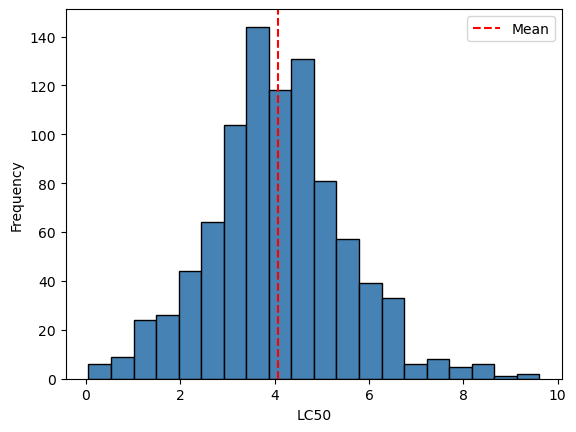

In [10]:
plt.hist(df["LC50"], bins=20, color="steelblue", edgecolor="black")
plt.axvline(df["LC50"].mean(), linestyle="--", label="Mean" ,color="red")
plt.xlabel("LC50")
plt.ylabel("Frequency")
plt.legend()
plt.show()

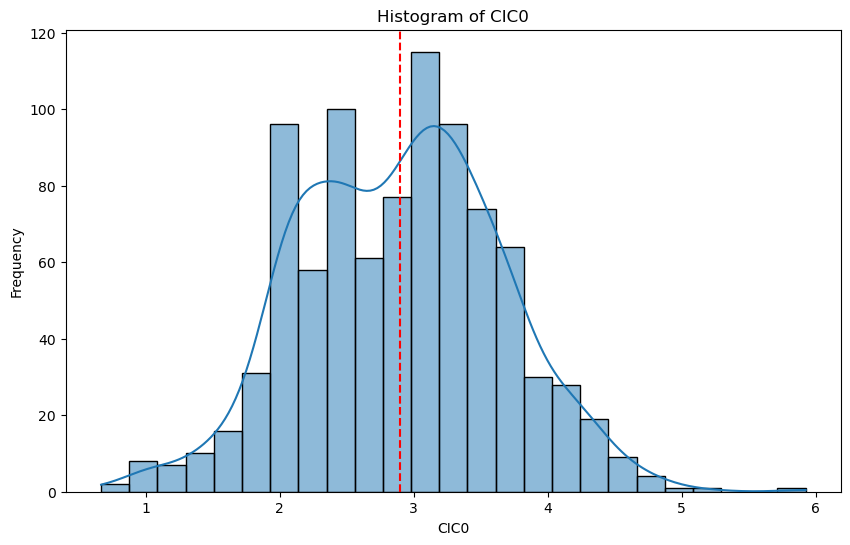

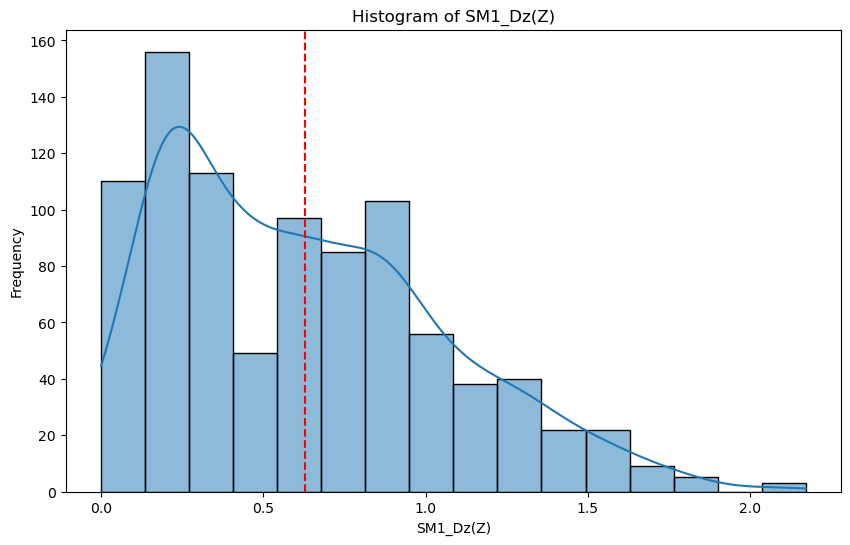

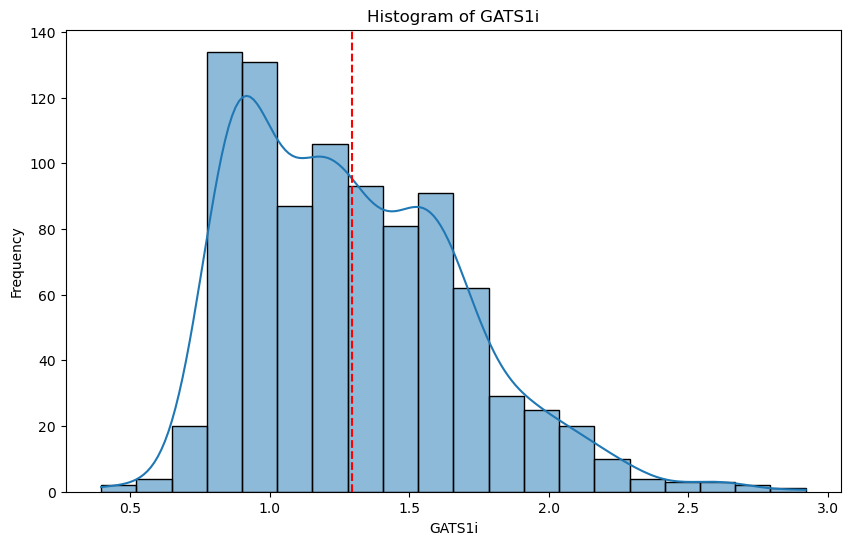

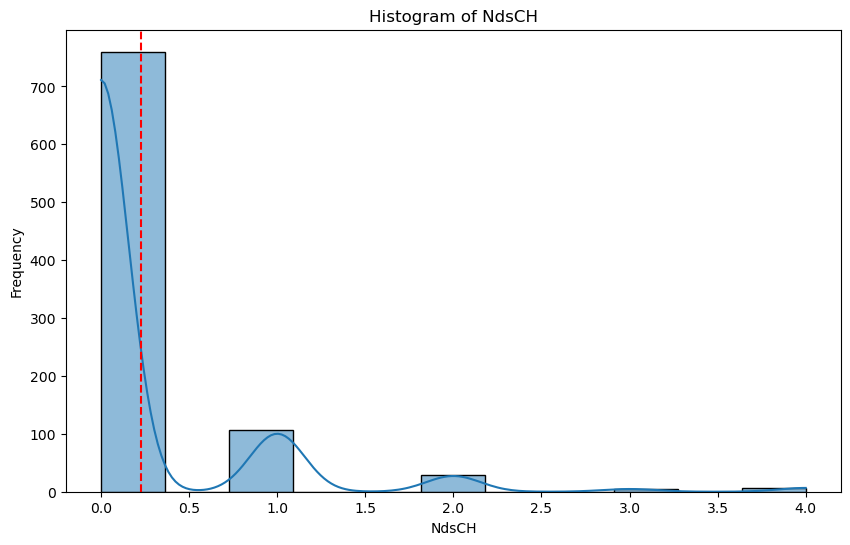

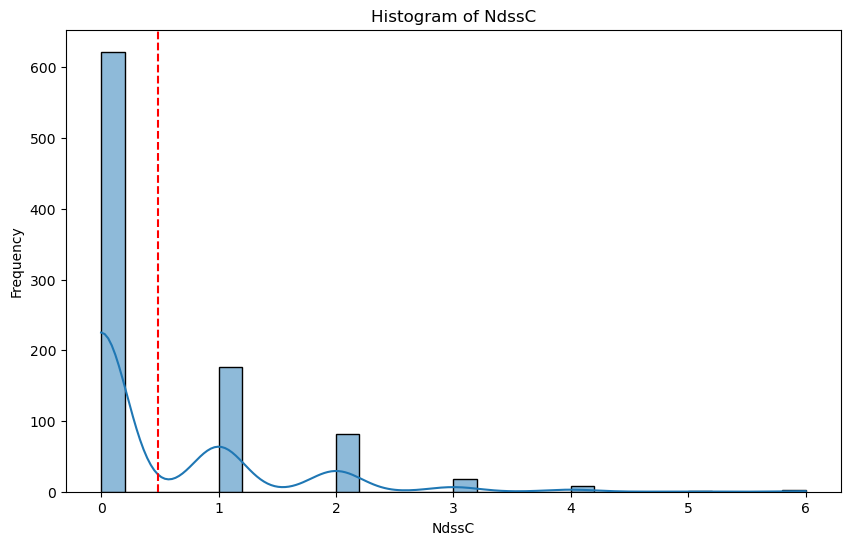

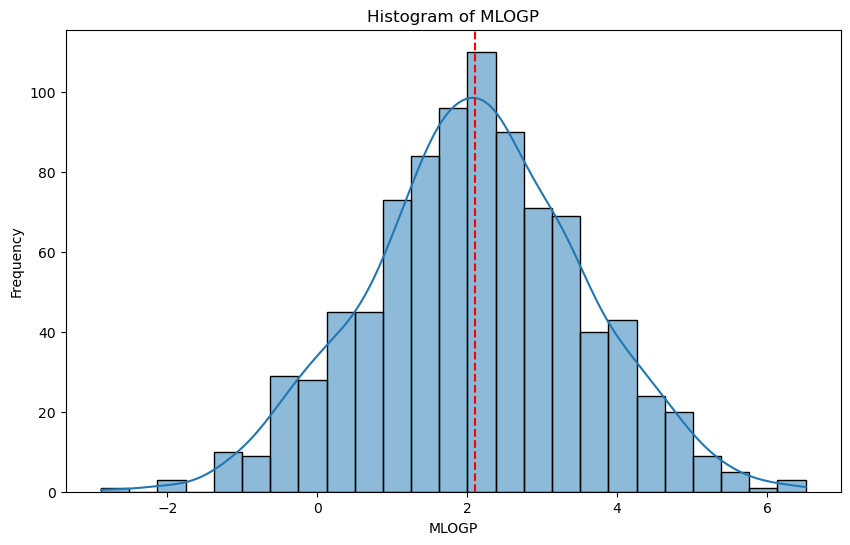

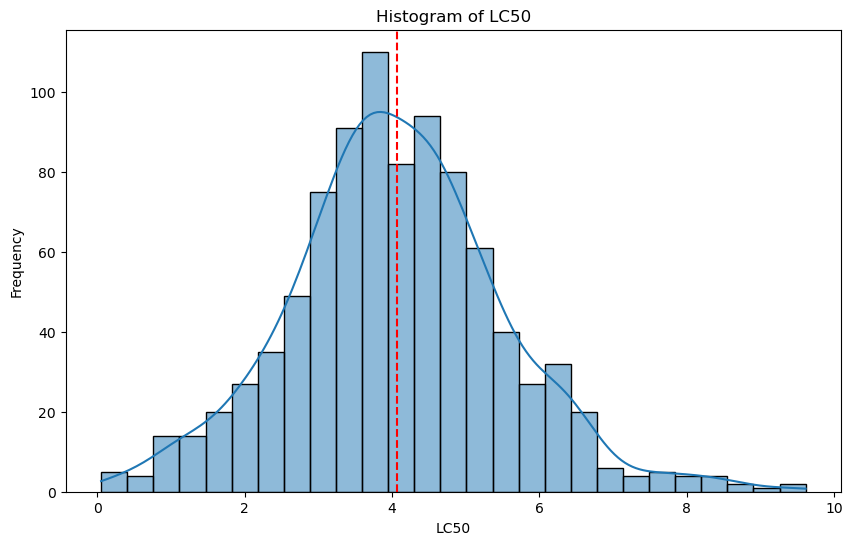

In [13]:
#This is a loop to iterate through each column in the data frame and create a histogram for each column. The histogram will show the distribution of the values in each column. 

#Define the function
def Qsar_histogram(df):

    for column in df.columns:
        plt.figure(figsize=(10, 6))
        #Histogram.
        sns.histplot(df[column], kde=True)
         # Mean line
        mean_value = df[column].mean()
        plt.axvline(mean_value, linestyle='--', label=f"Mean = {mean_value:.2f}", color="red")
        #labels and title
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show() 
#call the function.
Qsar_histogram(df)
   
  

In [11]:
#lest's check the correlation between the two most correlated features with LC50, which are NdsCH and NdssC.
df.corr()["LC50"]

CIC0         0.291854
SM1_Dz(Z)    0.410893
GATS1i      -0.397965
NdsCH        0.172004
NdssC        0.172390
MLOGP        0.651664
LC50         1.000000
Name: LC50, dtype: float64

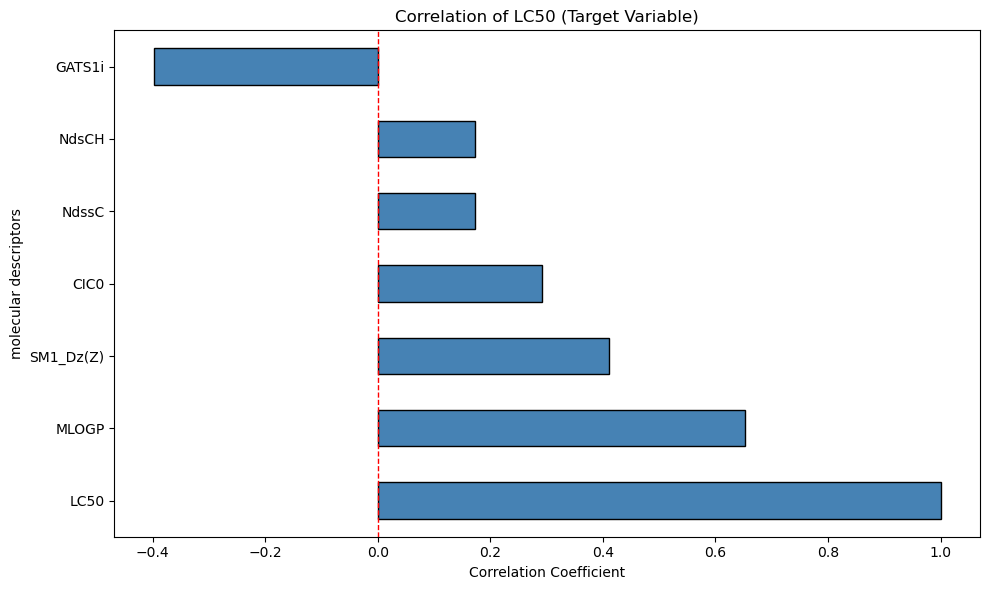

In [15]:
# Create a bar plot of correlations with LC50 the dependent variable.
plt.figure(figsize=(10, 6))
correlation_data = df.corr()["LC50"].sort_values(ascending=False)
correlation_data.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Correlation Coefficient')
plt.ylabel('molecular descriptors')
plt.title('Correlation of LC50 (Target Variable)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

#Now we see that: MLOGP is the most correlated feature with LC50.
                 # SM1_Dz(Z)show a moderate correlation with LC50.
                 #GATS1i has a negative correlation with LC50, which means that as GATS1i increases, LC50 decreases.
                 #NdsCH and NdssC have a very low correlation with LC50, which means that they are not good predictors of LC50.
                 #CICO has a very low correlation with LC50, which means that it is not a good predictor of LC50, but it is not as bad as NdsCH and NdssC 0.29  is enough work with it.


In [36]:
# Calculate the correlation matrix and assign it to a variable
corr = df.corr()
corr

,CIC0,SM1_Dz(Z),GATS1i,NdsCH,NdssC,MLOGP,LC50
CIC0,1.000000,-0.235360,0.147622,0.121341,0.246639,0.463867,0.291854
SM1_Dz(Z),-0.235360,1.000000,-0.145967,-0.141401,0.163179,0.200663,0.410893
GATS1i,0.147622,-0.145967,1.000000,-0.010657,0.092410,-0.450739,-0.397965
NdsCH,0.121341,-0.141401,-0.010657,1.000000,0.188164,0.048620,0.172004
NdssC,0.246639,0.163179,0.092410,0.188164,1.000000,0.028499,0.172390
MLOGP,0.463867,0.200663,-0.450739,0.048620,0.028499,1.000000,0.651664
LC50,0.291854,0.410893,-0.397965,0.172004,0.172390,0.651664,1.000000


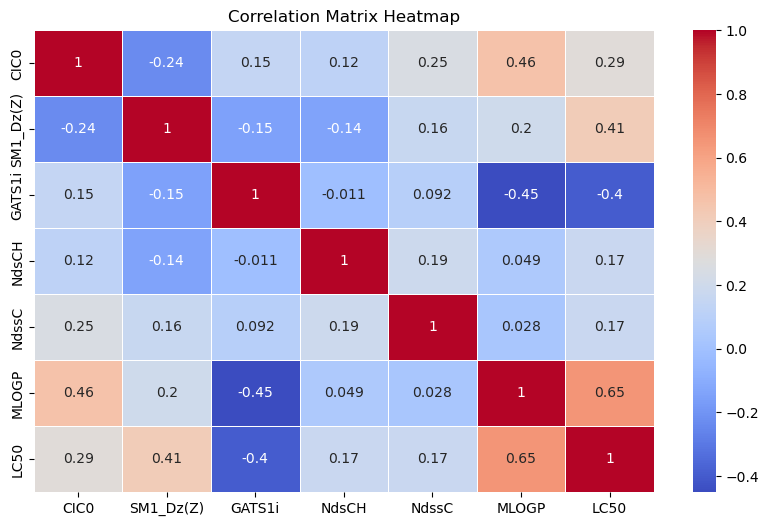

In [23]:
#lest's visualize the correlation matrix with a heatmap. This will help us to see the correlation between all the features and the target variable LC50.
corr = df.corr()
plt.figure(figsize=(10, 6)) 
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

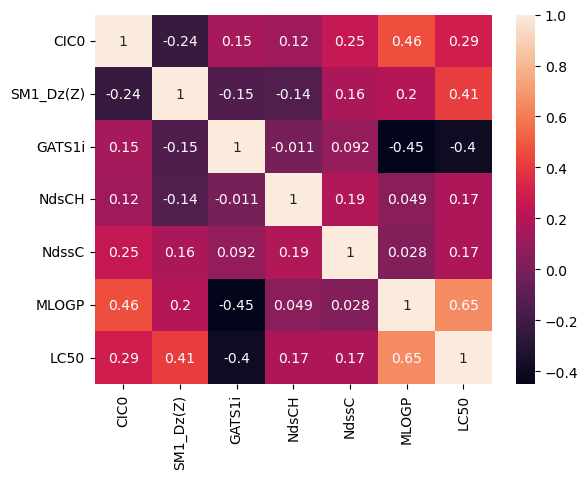

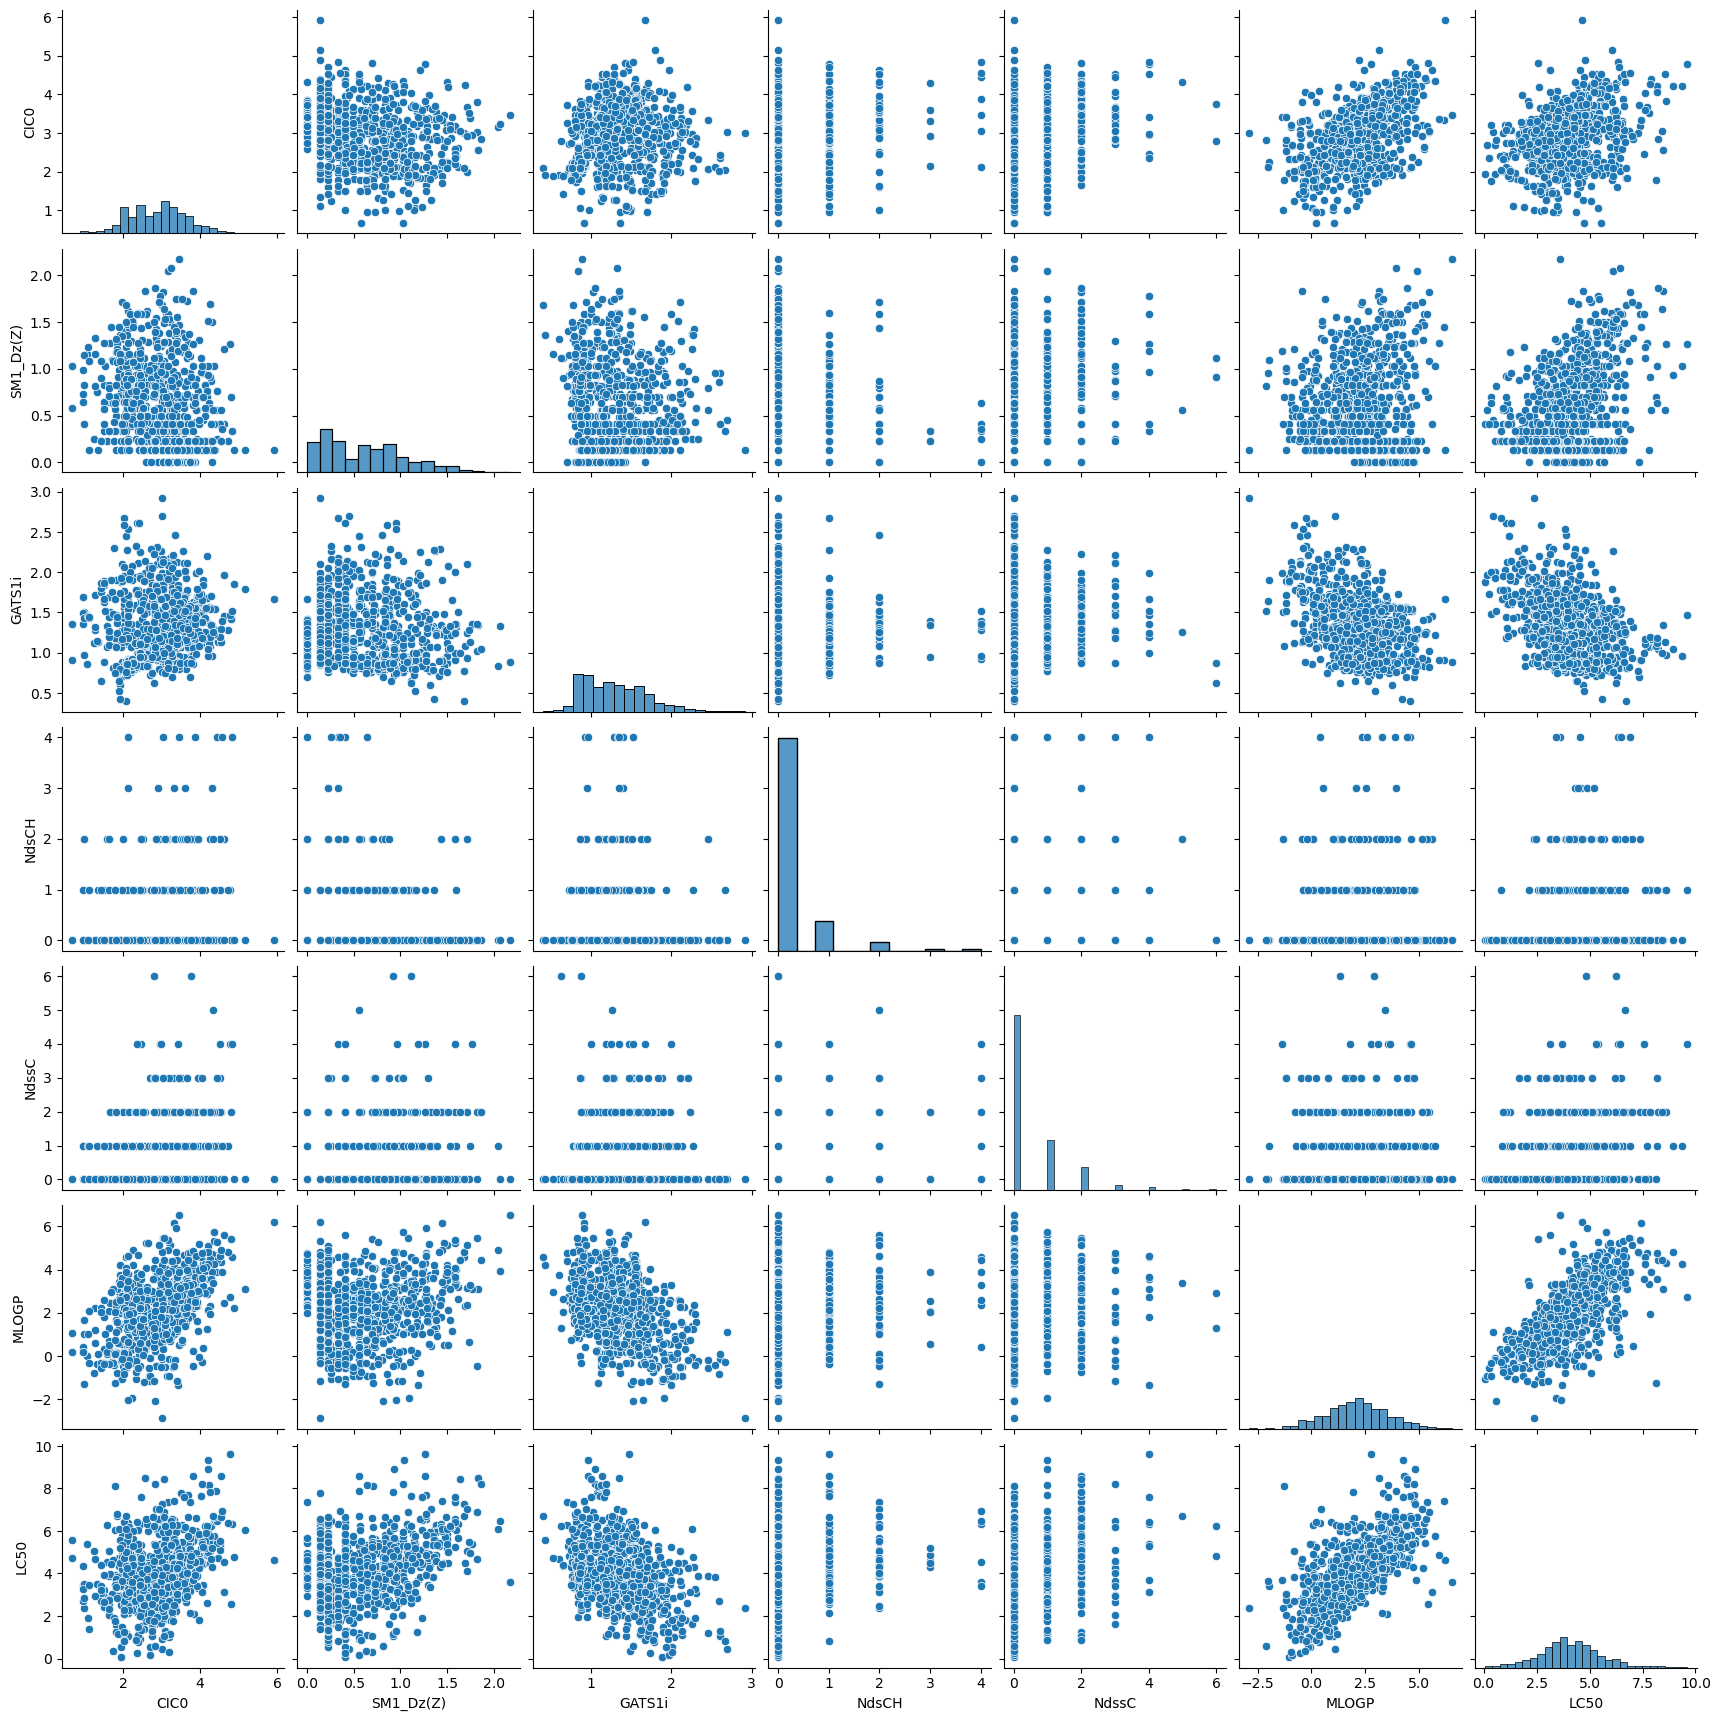

In [12]:
df.corr()
sns.heatmap(df.corr(), annot=True)
sns.pairplot(df)

In [ ]:
#Let's check the correlation between the two most correlated features with LC50, which are NdsCH and NdssC.
print(df[['NdsCH', 'NdssC']].corr())

          NdsCH     NdssC
NdsCH  1.000000  0.188164
NdssC  0.188164  1.000000
